In [1]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.0/112.6 GB disk)


In [2]:

SEG_MODEL = 'yolov8n-seg'
CLASS_NAME= 'Remote'
VAL_FRACTION = 0.2
IMG_SIZE= 640
BATCH= 8
EPOCHS_SCRATCH= 200
EPOCHS_FINETUNE = 100
SEED = 42


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

drive_zip_path = '/content/drive/MyDrive/dataset.zip'

with zipfile.ZipFile(drive_zip_path, 'r') as z:
    z.extractall('/content/raw_dataset')

print("Extracted contents:", os.listdir('/content/raw_dataset'))

Mounted at /content/drive
Extracted contents: ['dataset']


In [4]:
from ultralytics.data.converter import convert_coco
import shutil, glob, os

json_candidates = glob.glob('/content/raw_dataset/**/*.json', recursive=True)
assert len(json_candidates) == 1, f"Expected exactly one COCO json, found: {json_candidates}"
coco_json_path = json_candidates[0]
print("Using annotation file:", coco_json_path)

os.makedirs('/content/coco_ann', exist_ok=True)
shutil.copy(coco_json_path, '/content/coco_ann/')

convert_coco(
    labels_dir='/content/coco_ann/',
    save_dir='/content/converted',
    use_segments=True,
    cls91to80=False,
)

print("Converted label folder(s):", os.listdir('/content/converted/labels'))

Using annotation file: /content/raw_dataset/dataset/annotations.json
Annotations /content/coco_ann/annotations.json: 100% ━━━━━━━━━━━━ 50/50 8.2Kit/s 0.0s
COCO data converted successfully.
Results saved to /content/converted
Converted label folder(s): ['annotations']


In [9]:

import random, shutil
from pathlib import Path

random.seed(SEED)
img_dir = Path('/content/raw_dataset/dataset/images')
label_root = Path('/content/converted/labels')
label_src_dir = next(label_root.iterdir())
print("Reading converted labels from:", label_src_dir)

dataset_root = Path('/content/dataset')
for split in ['train', 'val']:
    (dataset_root / 'images' / split).mkdir(parents=True, exist_ok=True)
    (dataset_root / 'labels' / split).mkdir(parents=True, exist_ok=True)

image_files = sorted([f for f in img_dir.glob('*') if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
random.shuffle(image_files)

val_count = max(1, round(VAL_FRACTION * len(image_files)))
val_files = image_files[:val_count]
train_files = image_files[val_count:]

def place(files_list, split):
    for img_path in files_list:
        label_path = label_src_dir / (img_path.stem + '.txt')
        shutil.copy(img_path, dataset_root / 'images' / split / img_path.name)
        if label_path.exists():
            shutil.copy(label_path, dataset_root / 'labels' / split / (img_path.stem + '.txt'))
        else:
            print(f"No label for {img_path.name} -- check this image is annotated in your COCO json")

place(train_files, 'train')
place(val_files, 'val')

print(f"Train: {len(train_files)} images | Val: {len(val_files)} images")


Reading converted labels from: /content/converted/labels/annotations
Train: 40 images | Val: 10 images


In [6]:
data_yaml_content = f"""path: /content/dataset
train: images/train
val: images/val

names:
  0: {CLASS_NAME}
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(data_yaml_content)

print(data_yaml_content)

path: /content/dataset
train: images/train
val: images/val

names:
  0: Remote



In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_yolo_seg_label(img_path, label_path):
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Warning: Could not load image from {img_path}. Skipping display.")
        return
    h, w = img.shape[:2]
    with open(label_path) as f:
        for line in f:
            vals = list(map(float, line.split()))
            coords = vals[1:]
            pts = np.array(coords).reshape(-1, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
            pts = pts.astype(np.int32)
            cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

sample_images_list = list((dataset_root / 'images' / 'train').glob('*'))
if not sample_images_list:
    print("Error: No training images found in '/content/dataset/images/train'. Please verify the data loading and splitting steps in previous cells.")
else:
    sample_img = sample_images_list[0]
    sample_label = dataset_root / 'labels' / 'train' / (sample_img.stem + '.txt')
    show_yolo_seg_label(sample_img, sample_label)


Error: No training images found in '/content/dataset/images/train'. Please verify the data loading and splitting steps in previous cells.


## Approach 1 — Train from scratch

In [10]:
from ultralytics import YOLO

model_scratch = YOLO(f'{SEG_MODEL}.yaml')
results_scratch = model_scratch.train(
    data='/content/dataset/data.yaml',
    epochs=EPOCHS_SCRATCH,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=0,
    patience=50,
    project='/content/runs/segment',
    name='scratch_remote',
    pretrained=False,
)

Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=scratch_remote, nbs=64, nms=

## Approach 2 — Fine-tune

In [11]:
model_finetune = YOLO(f'{SEG_MODEL}.pt')

results_finetune = model_finetune.train(
    data='/content/dataset/data.yaml',
    epochs=EPOCHS_FINETUNE,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=0,
    patience=20,
    project='/content/runs/segment',
    name='finetune_remote',
)

Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune_remote, nbs=64, nms=F

## Comparison

In [12]:
metrics_scratch = model_scratch.val(data='/content/dataset/data.yaml')
metrics_finetune = model_finetune.val(data='/content/dataset/data.yaml')

print("=== FROM SCRATCH ===")
for k, v in metrics_scratch.results_dict.items():
    print(f"{k}: {v:.4f}")

print("\n=== FINE-TUNED ===")
for k, v in metrics_finetune.results_dict.items():
    print(f"{k}: {v:.4f}")

Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5288.0±1004.7 MB/s, size: 2647.6 KB)
val: Scanning /content/dataset/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5s/it 1.5s
                   all         10         10      0.337        0.4      0.328      0.154      0.404        0.5      0.396      0.256
Speed: 0.4ms preprocess, 8.6ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/segment/val
Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image ac

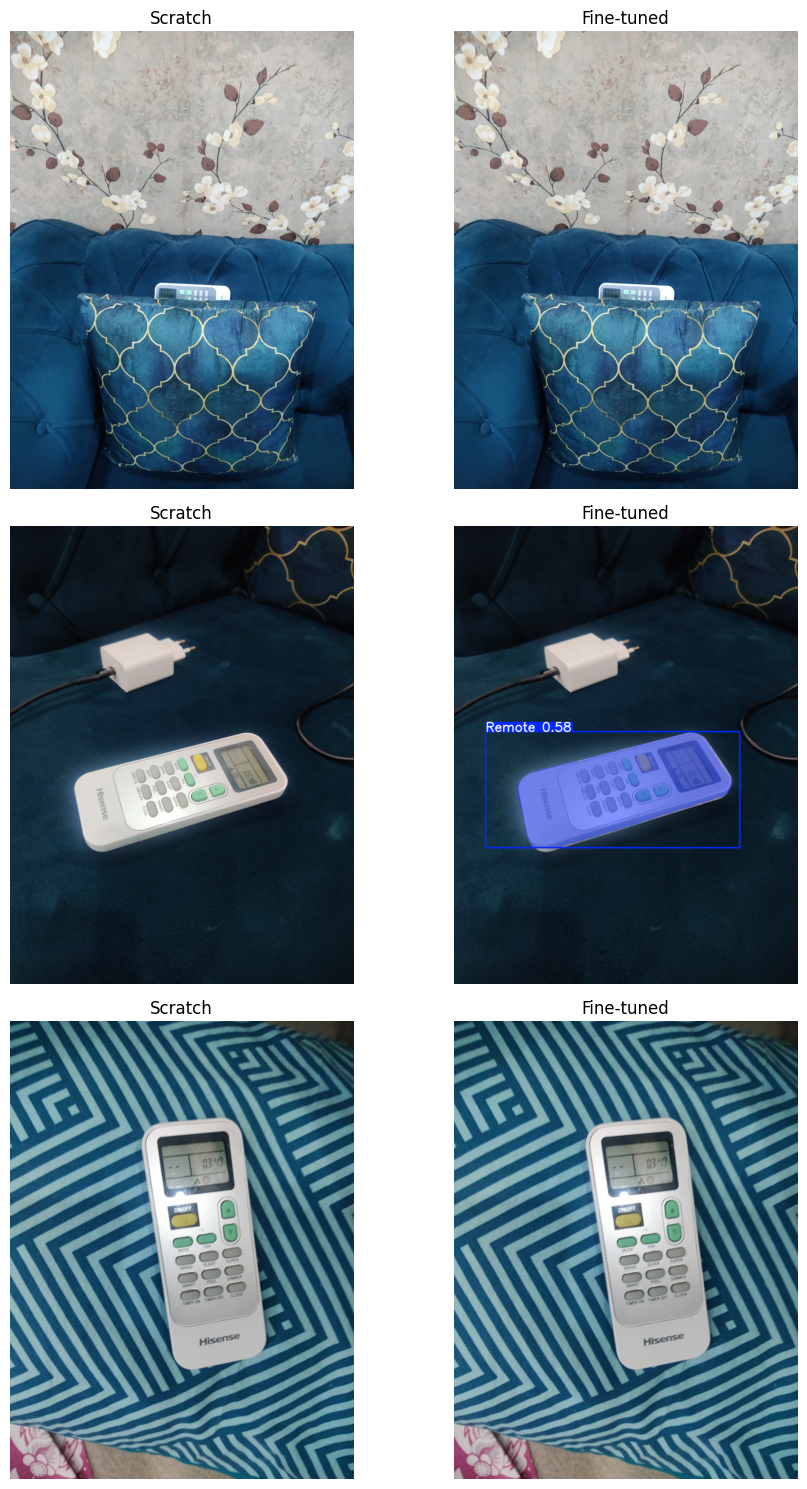

In [13]:
val_images = list((dataset_root / 'images' / 'val').glob('*'))[:3]

fig, axes = plt.subplots(len(val_images), 2, figsize=(10, 5 * len(val_images)))
if len(val_images) == 1:
    axes = axes.reshape(1, 2)

for i, img_path in enumerate(val_images):
    pred_scratch = model_scratch.predict(str(img_path), verbose=False)[0]
    pred_finetune = model_finetune.predict(str(img_path), verbose=False)[0]

    axes[i, 0].imshow(cv2.cvtColor(pred_scratch.plot(), cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title('Scratch')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cv2.cvtColor(pred_finetune.plot(), cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title('Fine-tuned')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Saving results in google drive

In [14]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/remote_segmentation_results
!cp -r /content/runs/segment/scratch_remote /content/drive/MyDrive/remote_segmentation_results/
!cp -r /content/runs/segment/finetune_remote /content/drive/MyDrive/remote_segmentation_results/

print("Saved to Google Drive: MyDrive/remote_segmentation_results/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive: MyDrive/remote_segmentation_results/
